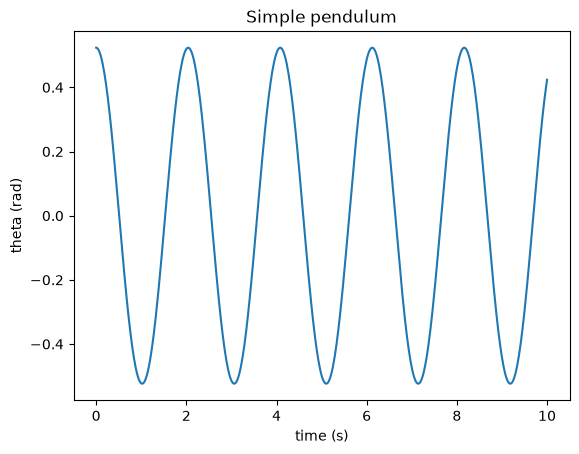

Measured period:           2.040990 s  (spread 6.73e-12 s)


In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.special import ellipk
import matplotlib.pyplot as plt

g = 9.81      # m/s^2
L = 1.0       # m

def pendulum(t, y):
    theta, omega = y
    dtheta_dt = omega
    domega_dt = -(g / L) * np.sin(theta)
    return [dtheta_dt, domega_dt]

theta0 = np.radians(30)    # start at 30 degrees
omega0 = 0.0               # released from rest
y0 = [theta0, omega0]

t_span = (0, 10)
t_eval = np.linspace(0, 10, 500)


def theta_zero(t, y):
    return y[0]

theta_zero.direction = -1     # only count crossings with theta decreasing
theta_zero.terminal = False

sol = solve_ivp(pendulum, t_span, y0, t_eval=t_eval,
                events=theta_zero, rtol=1e-10, atol=1e-12)

crossings = sol.t_events[0]
periods = np.diff(crossings)    

T_measured = periods.mean()
T_std = periods.std()

plt.plot(sol.t, sol.y[0])
plt.xlabel('time (s)')
plt.ylabel('theta (rad)')
plt.title('Simple pendulum')
plt.show()

print(f"Measured period:           {T_measured:.6f} s  (spread {T_std:.2e} s)")
